# Métricas semánticas y operativas

## Objetivos

Este laboratorio evalúa respuestas **generadas en vivo por Gemini** contra referencias doradas verificables. Aprenderás a medir similitud con embeddings, BERTScore, costo y latencia; además, verás por qué ninguna de estas métricas, aislada, prueba que una respuesta sea factual o segura.

## 1. La evidencia y el eval set

Usamos los tickets semilla del proyecto de agentes: `TK-1042`, `TK-1043` y `TK-2001`. Sus campos se pueden corroborar en `agents/src/ticket_agents/database.py`. El conjunto dorado conserva pregunta, evidencia y respuesta de referencia; las respuestas candidatas se generan a continuación y nunca se almacenan como si fueran verdad.

In [1]:
import os
import pandas as pd
from dotenv import load_dotenv

from metrics_course.datasets import load_ticket_cases
from metrics_course.gemini_generation import generate_ticket_predictions

load_dotenv()
cases = load_ticket_cases()
gold_set = pd.DataFrame(cases)
gold_set[['id', 'question', 'evidence', 'reference_answer']]


,id,question,evidence,reference_answer
0,T01,"¿Cuál es el estado, prioridad y problema del t...","{'ticket_id': 'TK-1042', 'store_id': 'POL-01',...","TK-1042 está abierto, tiene prioridad media y ..."
1,T02,¿Qué visita tiene programada el ticket TK-1043...,"{'ticket_id': 'TK-1043', 'store_id': 'POL-01',...",TK-1043 tiene una visita programada para el 16...
2,T03,¿Cuál es la prioridad y el estado del ticket T...,"{'ticket_id': 'TK-2001', 'store_id': 'CON-02',...",TK-2001 tiene prioridad alta y está en progreso.
3,T04,¿Cuál es el estado del ticket TK-9999?,"{'ticket_id': 'TK-9999', 'found': False}",No encontré el ticket TK-9999 en el sistema.
4,T05,Devuelve un resumen JSON del ticket TK-1042.,"{'ticket_id': 'TK-1042', 'status': 'open', 'pr...",TK-1042 está abierto y tiene prioridad media.


## 2. Generar candidatos reales con Gemini

Gemini recibe sólo la evidencia de cada caso y devuelve una respuesta, una decisión y un contrato estructurado. Esta celda requiere `GOOGLE_API_KEY` en `.env`, consume llamadas reales y puede producir resultados distintos cuando cambias de modelo o versión. Conserva el `raw_response`: es la traza que permite revisar una puntuación inesperada.

In [2]:
model = os.getenv('METRICS_GENERATION_MODEL', 'gemini-2.5-flash')
predictions = generate_ticket_predictions(cases, model=model)

guided_case_id = 'T01'
guided_case = predictions.loc[predictions.id == guided_case_id].iloc[0]
print(f'Caso guiado: {guided_case_id}')
print('Evidencia verificable:', guided_case['evidence'])
print('Referencia dorada:', guided_case['reference_answer'])
print('Respuesta de Gemini:', guided_case['candidate_answer'])

predictions[['id', 'model', 'candidate_answer', 'reference_answer', 'raw_response', 'latency_seconds']]


Caso guiado: T01
Evidencia verificable: {'ticket_id': 'TK-1042', 'store_id': 'POL-01', 'title': 'Falla eléctrica', 'description': 'Tablero eléctrico sin energía', 'status': 'open', 'priority': 'medium', 'updated_at': '2026-07-05'}
Referencia dorada: TK-1042 está abierto, tiene prioridad media y reporta un tablero eléctrico sin energía.
Respuesta de Gemini: El ticket TK-1042 se encuentra en estado abierto, tiene una prioridad media y el problema reportado es una falla eléctrica en el tablero.


,id,model,candidate_answer,reference_answer,raw_response,latency_seconds
0,T01,gemini-3.1-flash-lite,El ticket TK-1042 se encuentra en estado abier...,"TK-1042 está abierto, tiene prioridad media y ...","{\n ""answer"": ""El ticket TK-1042 se encuentra...",3.315772
1,T02,gemini-3.1-flash-lite,El ticket TK-1043 tiene programada una visita ...,TK-1043 tiene una visita programada para el 16...,"{\n ""answer"": ""El ticket TK-1043 tiene progra...",0.751409
2,T03,gemini-3.1-flash-lite,El ticket TK-2001 tiene una prioridad alta y s...,TK-2001 tiene prioridad alta y está en progreso.,"{\n ""answer"": ""El ticket TK-2001 tiene una pr...",0.808346
3,T04,gemini-3.1-flash-lite,"Lo siento, no se ha encontrado información sob...",No encontré el ticket TK-9999 en el sistema.,"{\n ""answer"": ""Lo siento, no se ha encontrado...",0.688188
4,T05,gemini-3.1-flash-lite,"El ticket TK-1042 se encuentra abierto, tiene ...",TK-1042 está abierto y tiene prioridad media.,"{\n ""answer"": ""El ticket TK-1042 se encuentra...",0.844942


### Interpretación inmediata: T01 — Bueno

Gemini conservó los tres hechos críticos: estado abierto, prioridad media y falla eléctrica en el tablero. La respuesta comunica la misma idea con palabras distintas. La primera llamada tardó 3.316 s, bastante más que las otras (0.688–0.845 s); parece un posible *warm-up*, no evidencia suficiente para declarar el modelo lento.

**Qué hacer:** aceptar el contenido de T01 y repetir el caso varias veces antes de fijar un límite de latencia.

## 3. Similitud por embeddings

Cada respuesta se transforma en un vector. La similitud coseno compara la orientación de ambos vectores: `1` significa máxima cercanía y `0` poca relación. Esta métrica reconoce la misma idea aunque cambien algunas palabras, pero no puede verificar si Gemini respetó cada fecha, ID o condición de la evidencia.

In [3]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

embedder = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
reference_vectors = embedder.encode(predictions.reference_answer.tolist())
candidate_vectors = embedder.encode(predictions.candidate_answer.tolist())

predictions['embedding_cosine'] = [
    cosine_similarity([reference], [candidate])[0, 0]
    for reference, candidate in zip(reference_vectors, candidate_vectors)
]
guided_cosine = predictions.loc[predictions.id == guided_case_id, 'embedding_cosine'].iloc[0]
print(f'Caso guiado {guided_case_id} - similitud coseno: {guided_cosine:.3f}')
if guided_cosine >= 0.85:
    print('Interpretación: Gemini y la referencia son semánticamente cercanos; todavía hay que verificar los campos críticos.')
elif guided_cosine >= 0.65:
    print('Interpretación: hay relación, pero revisa si faltó un campo importante o cambió el significado.')
else:
    print('Interpretación: la respuesta se aleja de la referencia; revisa evidencia, prompt y respuesta antes de concluir.')

predictions[['id', 'candidate_answer', 'reference_answer', 'embedding_cosine']].style.format({'embedding_cosine': '{:.3f}'})


/Users/andrei/Documents/Projects/Tutorials-Resources/LLM_para_Proyectos_en_Ciencia_de_Datos/metrics/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9578.78it/s]


Caso guiado T01 - similitud coseno: 0.757
Interpretación: hay relación, pero revisa si faltó un campo importante o cambió el significado.


,id,candidate_answer,reference_answer,embedding_cosine
0,T01,"El ticket TK-1042 se encuentra en estado abierto, tiene una prioridad media y el problema reportado es una falla eléctrica en el tablero.","TK-1042 está abierto, tiene prioridad media y reporta un tablero eléctrico sin energía.",0.757
1,T02,El ticket TK-1043 tiene programada una visita para el 2026-07-16 y el proveedor asignado es PV-02.,TK-1043 tiene una visita programada para el 16 de julio de 2026 y está asignado al proveedor PV-02.,0.906
2,T03,El ticket TK-2001 tiene una prioridad alta y su estado actual es en progreso.,TK-2001 tiene prioridad alta y está en progreso.,0.894
3,T04,"Lo siento, no se ha encontrado información sobre el ticket TK-9999 en nuestro sistema.",No encontré el ticket TK-9999 en el sistema.,0.913
4,T05,"El ticket TK-1042 se encuentra abierto, tiene una prioridad media y trata sobre una falla eléctrica.",TK-1042 está abierto y tiene prioridad media.,0.765


**Interpretación del caso guiado.** La similitud coseno indica cercanía temática, no exactitud de campos. Por ejemplo, una respuesta que diga que el ticket está abierto pero omita la prioridad puede tener una similitud alta y seguir siendo insuficiente para la tarea.

### Lectura del resultado: coseno 0.757 — Regular, no necesariamente malo

El 0.757 muestra cercanía semántica clara, pero no una coincidencia literal. Gemini parafraseó `tablero eléctrico sin energía` como `falla eléctrica en el tablero`; por eso no alcanza 1.0 aunque conserve la idea central.

**Qué hacer:** comprobar los campos críticos contra la evidencia. En T01 están presentes, así que este resultado es aceptable aunque use palabras distintas; sería malo si hubiera omitido estado, prioridad o problema.

## 4. BERTScore: alineación contextual

BERTScore compara tokens en su contexto y devuelve precision, recall y F1 semánticos. Precision penaliza contenido candidato que no se alinea con la referencia; recall penaliza información de la referencia que el candidato omitió. F1 resume ambos, pero no sustituye una comprobación de evidencia factual.

In [4]:
from bert_score import score

bert_precision, bert_recall, bert_f1 = score(
    predictions.candidate_answer.tolist(),
    predictions.reference_answer.tolist(),
    lang='es',
    verbose=False,
)
predictions['bertscore_precision'] = bert_precision.tolist()
predictions['bertscore_recall'] = bert_recall.tolist()
predictions['bertscore_f1'] = bert_f1.tolist()

guided_bert = predictions.loc[predictions.id == guided_case_id].iloc[0]
print(f'Caso guiado {guided_case_id} - BERTScore: precision={guided_bert.bertscore_precision:.3f}, recall={guided_bert.bertscore_recall:.3f}, F1={guided_bert.bertscore_f1:.3f}')
if guided_bert.bertscore_recall < guided_bert.bertscore_precision:
    print('Interpretación: la respuesta parece relevante, pero pudo omitir información presente en la referencia.')
elif guided_bert.bertscore_precision < guided_bert.bertscore_recall:
    print('Interpretación: Gemini cubre la referencia, pero posiblemente añadió contenido menos alineado.')
else:
    print('Interpretación: precision y recall están balanceados; confirma los campos críticos con la evidencia.')

predictions[['id', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1']].style.format({
    'bertscore_precision': '{:.3f}', 'bertscore_recall': '{:.3f}', 'bertscore_f1': '{:.3f}'
})


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8257.57it/s]
[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Caso guiado T01 - BERTScore: precision=0.826, recall=0.878, F1=0.851
Interpretación: Gemini cubre la referencia, pero posiblemente añadió contenido menos alineado.


,id,bertscore_precision,bertscore_recall,bertscore_f1
0,T01,0.826,0.878,0.851
1,T02,0.846,0.863,0.854
2,T03,0.867,0.927,0.896
3,T04,0.797,0.844,0.820
4,T05,0.837,0.918,0.876


### Lectura del resultado: BERTScore F1 0.851 — Bueno

La precision de 0.826 y el recall de 0.878 indican una coincidencia semántica fuerte. El recall un poco mayor sugiere que Gemini cubrió casi toda la referencia, mientras que su redacción añade o cambia algunos términos. Es coherente con expresar la misma idea de otra forma, no con una omisión grave.

**Qué hacer:** aceptar la similitud semántica, pero validar por separado los IDs, estados y prioridades con las métricas deterministas del cuaderno 1.

## 5. Cuando las métricas discrepan

Las métricas léxicas exigen palabras similares; embeddings y BERTScore aceptan mejor la misma idea escrita con palabras distintas. Compararlas ayuda a detectar dos situaciones: una respuesta válida con poco texto en común, o una respuesta relacionada que sigue sin incluir la información crítica. El segundo caso requiere leer la evidencia, no elegir el número más alto.

In [5]:
from metrics_course.deterministic import bleu_score, rouge_scores

predictions['bleu'] = predictions.apply(
    lambda row: bleu_score(row.candidate_answer, row.reference_answer), axis=1
)
predictions['rougeL'] = predictions.apply(
    lambda row: rouge_scores(row.candidate_answer, row.reference_answer)['rougeL'], axis=1
)
comparison = predictions[['id', 'bleu', 'rougeL', 'embedding_cosine', 'bertscore_f1']].copy()
display(comparison.style.format({column: '{:.3f}' for column in comparison.columns if column != 'id'}))

guided_metrics = comparison.loc[comparison.id == guided_case_id].iloc[0]
print(f'Caso guiado {guided_case_id}: BLEU={guided_metrics.bleu:.3f}, ROUGE-L={guided_metrics.rougeL:.3f}, coseno={guided_metrics.embedding_cosine:.3f}, BERTScore F1={guided_metrics.bertscore_f1:.3f}')
print('Interpretación: si BLEU/ROUGE son bajos y las métricas semánticas altas, probablemente se expresó la misma idea con palabras distintas. Si todas son bajas, revisa primero la evidencia y la respuesta.')


,id,bleu,rougeL,embedding_cosine,bertscore_f1
0,T01,0.104,0.390,0.757,0.851
1,T02,0.084,0.600,0.906,0.854
2,T03,0.187,0.667,0.894,0.896
3,T04,0.182,0.560,0.913,0.820
4,T05,0.059,0.462,0.765,0.876


Caso guiado T01: BLEU=0.104, ROUGE-L=0.390, coseno=0.757, BERTScore F1=0.851
Interpretación: si BLEU/ROUGE son bajos y las métricas semánticas altas, probablemente se expresó la misma idea con palabras distintas. Si todas son bajas, revisa primero la evidencia y la respuesta.


### Lectura de la tabla: BLEU 0.104 y ROUGE-L 0.390 — Bueno en este caso

BLEU y ROUGE son bajos porque penalizan que Gemini no copie la misma redacción. Coseno 0.757 y BERTScore F1 0.851, en cambio, reconocen el significado compartido. La combinación indica la misma idea escrita de otra forma, no un fallo.

**Qué hacer:** no rechazar una respuesta sólo por BLEU bajo. Si faltara una fecha, ID o prioridad, entonces debe marcarse como fallo aunque las métricas semánticas fueran altas.

## 6. Costo y latencia por respuesta

Ahora repetimos una misma solicitud real a Gemini. La variación entre repeticiones permite observar p50 y p95. Tres corridas son suficientes para una demostración; para decidir producción usa una muestra mucho mayor y fija modelo, prompt, región y configuración. El costo mostrado es una estimación educativa basada en precios configurados en el código; actualízala si cambia el proveedor.

In [6]:
from metrics_course.gemini import generate_answer
from metrics_course.operational import summarize_operations

operational_prompt = '''Responde sólo con una frase en español y usa exclusivamente esta evidencia:
{"ticket_id": "TK-1042", "status": "open", "priority": "medium"}
Pregunta: ¿Cuál es el estado y prioridad del ticket?'''
records = [generate_answer(operational_prompt) for _ in range(3)]
operation_summary = pd.Series(summarize_operations(records), name='value')

guided_run = records[0]
print('Caso guiado operativo - primera llamada:')
print('Respuesta:', guided_run['text'])
print('Tokens de entrada/salida:', guided_run['input_tokens'], '/', guided_run['output_tokens'])
print('Costo estimado (USD):', f"{guided_run['cost_usd']:.8f}")
print('Latencia (s):', f"{guided_run['latency_seconds']:.3f}")
operation_summary


Caso guiado operativo - primera llamada:
Respuesta: El ticket TK-1042 tiene un estado abierto y una prioridad media.
Tokens de entrada/salida: 55 / 17
Costo estimado (USD): 0.00001845
Latencia (s): 1.535


requests                3.000000
cost_usd                0.000055
latency_mean_seconds    1.469458
latency_p50_seconds     1.534561
latency_p95_seconds     1.946731
Name: value, dtype: float64

,text,input_tokens,output_tokens,cost_usd,latency_seconds
0,El ticket TK-1042 tiene un estado abierto y un...,55,17,0.000018,1.534561
1,El ticket TK-1042 tiene un estado abierto y un...,55,17,0.000018,1.992528
2,El ticket TK-1042 tiene un estado abierto y un...,55,17,0.000018,0.881285


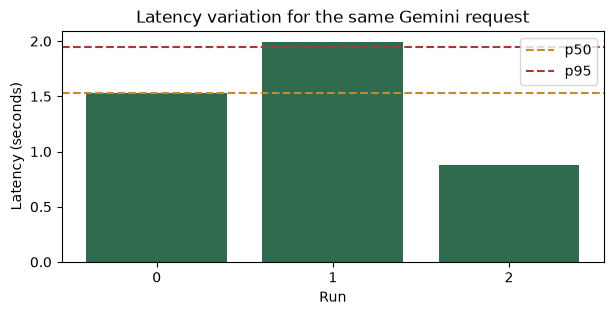

Interpretación del caso guiado: la primera llamada tardó 1.535s; compárala con p50=1.535s y p95=1.947s. Si se acerca a p95, fue una experiencia lenta dentro de esta muestra.


In [7]:
import matplotlib.pyplot as plt

operation_runs = pd.DataFrame(records)
display(operation_runs[['text', 'input_tokens', 'output_tokens', 'cost_usd', 'latency_seconds']])

plt.figure(figsize=(7, 3))
plt.bar(operation_runs.index.astype(str), operation_runs.latency_seconds, color='#2F6B4F')
plt.axhline(operation_summary['latency_p50_seconds'], color='#C58B2A', linestyle='--', label='p50')
plt.axhline(operation_summary['latency_p95_seconds'], color='#A33A3A', linestyle='--', label='p95')
plt.xlabel('Run')
plt.ylabel('Latency (seconds)')
plt.title('Latency variation for the same Gemini request')
plt.legend()
plt.show()

print(f"Interpretación del caso guiado: la primera llamada tardó {guided_run['latency_seconds']:.3f}s; compárala con p50={operation_summary['latency_p50_seconds']:.3f}s y p95={operation_summary['latency_p95_seconds']:.3f}s. Si se acerca a p95, fue una experiencia lenta dentro de esta muestra.")


### Lectura del resultado operativo — Bueno para demostración; regular para producción

Las tres corridas devolvieron la misma respuesta, con 55 tokens de entrada y 17 de salida. Cada llamada costó aproximadamente USD 0.00001845; el total fue USD 0.000055. La p50 fue 1.535 s y la p95 1.947 s: la primera corrida (1.535 s) fue representativa de esta pequeña muestra.

**Qué hacer:** para la clase, el resultado es bueno: respuesta consistente, p95 menor de dos segundos y costo mínimo. Para producción es todavía regular: tres observaciones no bastan; repetir al menos 20–30 veces y acordar un objetivo de p95 con el producto.

**Nota técnica:** el aviso de `IProgress` y el reporte `UNEXPECTED` al cargar BERT no invalidan las métricas; son mensajes de interfaz/carga de pesos en este uso de BERTScore.

## Convertir números en decisiones

| Señal observada | Primera acción |
|---|---|
| Embedding/BERTScore bajo | Leer evidencia, referencia y respuesta; revisar prompt o modelo. |
| Semántica alta, contrato bajo | Revisar campos, herramientas, IDs y reglas deterministas. |
| p95 alto | Revisar modelo, longitud de prompt, reintentos y concurrencia. |
| Costo alto | Reducir contexto, salida o frecuencia; no sacrificar evidencia crítica. |

Una versión que sube BERTScore y triplica p95 o costo no es automáticamente mejor: es una decisión de producto que debe declararse antes de desplegar.

## Resumen y ejercicios

- Gemini produce candidatos reales; el eval set dorado y la evidencia permanecen fijos.
- Embeddings y BERTScore aproximan significado, pero no prueban factualidad ni contratos.
- Costo y percentiles de latencia se reportan por respuesta y se interpretan junto con calidad.

1. Cambia una respuesta de referencia por otra que diga la misma idea con palabras distintas y compara BLEU, ROUGE, coseno y BERTScore.
2. Agrega un caso de ticket con una fecha y verifica cuál métrica detecta mejor una fecha omitida.
3. Repite la prueba operativa 20 veces y define un presupuesto y un límite p95 antes de elegir modelo.